# 잔존수명 예측 모델

입력: 진동 피처 + t_abs(절대 경과 시간) + rpm_pred + initial_fault_intensity
출력: RUL (초)

Train 학습:
  각 1초 샘플의 피처 → 해당 시점의 실제 RUL

Validation 예측:
  마지막 epoch의 피처 → RUL 예측

Train4 : 후방 축방향 결함으로 축방향 하중이 크지만 결함이 특정 방향에 집중되어 전체 베어링 파괴까지 시간이 더 걸렸을 수 있음

In [19]:
# !pip install common_utils
# !pip install torch
# !pip install openpyxl

In [20]:
import numpy as np
import pandas as pd
import platform
import os, random
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from common_utils import (load_train_data, load_test_data,
                          get_feat_cols, add_trend_features, aggregate_epoch,
                          calc_score, plot_loo_results,
                          fix_seed, SEED, TRAIN_PATH, TEST_PATH)
import torch 
import torch.nn as nn 
from torch.utils.data import DataLoader, TensorDataset 

In [21]:
def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.family'] = 'AppleGothic'
    else:  # Linux (서버 환경)
        # 나눔 폰트 설치 후 사용
        # sudo apt-get install fonts-nanum
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                      capture_output=True)
        fm._load_fontmanager(try_read_cache=False)
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        font_prop = fm.FontProperties(fname=font_path)
        plt.rcParams['font.family'] = font_prop.get_name()

    plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

set_korean_font()

### 1. Best Model : XGB + ttf + sampleweight(말기 가중)

In [38]:
fix_seed()

XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
)

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
VALID_CUTOFFS = [0.2, 0.5, 0.8]
EXCLUDE_COLS  = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                 'rpm', 'train_id', 'test_id']


# ── 샘플 가중치 계산 ──────────────────────────────────────────
def calc_sample_weights(cutoff_values):
    """
    cutoff가 높을수록 (말기) 가중치 높게
    0.9 → 가중치 높음 / 0.1 → 가중치 낮음
    """
    co  = np.array(cutoff_values, dtype=np.float32)
    w   = co ** 2   # 제곱으로 말기 집중
    return (w / w.mean()).astype(np.float32)


# ── cutoff 기반 샘플 생성 ─────────────────────────────────────
def make_cutoff_samples(df, cutoffs):
    samples = []
    for tid in df['train_id'].unique():
        df_t = df[df['train_id'] == tid].copy()
        ttf  = float(df_t['ttf'].iloc[0])

        for co in cutoffs:
            cutoff_t = ttf * co
            df_cut   = df_t[df_t['t_abs'] <= cutoff_t]
            if len(df_cut) == 0:
                continue

            last_row = df_cut.loc[df_cut['t_abs'].idxmax()]
            rul      = float(ttf - last_row['t_abs'])
            samples.append({
                'train_id': tid,
                'cutoff':   co,
                'ttf':      ttf,
                'RUL':      rul,
                't_abs':    float(last_row['t_abs']),
                **{c: last_row[c] for c in df_cut.columns
                   if c not in EXCLUDE_COLS + ['train_id']}
            })
    return pd.DataFrame(samples)


# ── 데이터 로드 ───────────────────────────────────────────────
df_raw  = load_train_data()
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

df_train_s = make_cutoff_samples(df_feat, TRAIN_CUTOFFS)
df_valid_s = make_cutoff_samples(df_feat, VALID_CUTOFFS)

feat_cols = [c for c in df_train_s.columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]
print(f'피처 수: {len(feat_cols)}개')
print(f'Train 샘플: {len(df_train_s)}개 | Valid 샘플: {len(df_valid_s)}개')

# ── 학습 ─────────────────────────────────────────────────────
X_train  = df_train_s[feat_cols].values.astype(np.float32)
y_train  = df_train_s['ttf'].values.astype(np.float32)
weights  = calc_sample_weights(df_train_s['cutoff'].values)

fix_seed()
model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train, sample_weight=weights)
print('학습 완료')

# ── Valid 평가 ────────────────────────────────────────────────
X_valid      = df_valid_s[feat_cols].values.astype(np.float32)
pred_ttf     = model.predict(X_valid).astype(np.float32)
pred_rul_arr = np.maximum(pred_ttf - df_valid_s['t_abs'].values, 0)
act_rul_arr  = df_valid_s['RUL'].values

scores = [calc_score(a, p)
          for a, p in zip(act_rul_arr, pred_rul_arr)]

print('\n=== Model G: 1초 XGBoost + TTF + sample_weight ===')
for co in VALID_CUTOFFS:
    mask   = df_valid_s['cutoff'].values == co
    s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
    mae_co = float(np.mean(np.abs(act_rul_arr[mask] - pred_rul_arr[mask])))
    print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')

avg_score = float(np.mean(scores))
print(f'\n  전체 평균 Score: {avg_score:.4f}')

print('\n  === Train별 20% 시점 예측 ===')
mask_20 = df_valid_s['cutoff'].values == 0.2
df_v20  = df_valid_s[mask_20].reset_index(drop=True)
p20     = pred_rul_arr[mask_20]
for i, row in df_v20.iterrows():
    a = row['RUL']
    p = p20[i]
    s = calc_score(a, p)
    print(f'  Train{int(row["train_id"])} | '
          f'실제={a:.0f}s | 예측={p:.0f}s | Score={s:.4f}')

modelG_score = avg_score

# ── Test 예측 + 제출 파일 ─────────────────────────────────────
df_test = load_test_data()
if df_test is not None:
    df_test = add_trend_features(df_test, windows=[5, 10],
                                  group_col='test_id')
    df_test = df_test.copy().fillna(0)

    results = []
    for tid in sorted(df_test['test_id'].unique()):
        df_t     = df_test[df_test['test_id'] == tid]
        last_row = df_t.loc[df_t['t_abs'].idxmax()]

        feat_vals = np.array([
            last_row[c] if c in last_row.index else 0.0
            for c in feat_cols
        ]).reshape(1, -1).astype(np.float32)

        pred_ttf_val = float(model.predict(feat_vals)[0])
        pred_rul     = max(pred_ttf_val - float(last_row['t_abs']), 0)

        results.append({'File': f'Test{tid}',
                         'RUL_Score': round(pred_rul, 2)})
        print(f'Test{tid} | {pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

    os.makedirs('../output', exist_ok=True)
    pd.DataFrame(results).to_excel(
        '../output/0605Best_model_submission.xlsx', index=False)
    print('\n=== 제출 파일 (Model:XGB+ttf+sampleweight ) ===')
    print(pd.DataFrame(results).to_string(index=False))

피처 수: 191개
Train 샘플: 24개 | Valid 샘플: 12개
학습 완료

=== Model G: 1초 XGBoost + TTF + sample_weight ===
  cutoff=20% | Score=0.9931 | MAE=135s
  cutoff=50% | Score=0.9442 | MAE=713s
  cutoff=80% | Score=0.6977 | MAE=2088s

  전체 평균 Score: 0.8783

  === Train별 20% 시점 예측 ===
  Train1 | 실제=60202s | 예측=60251s | Score=0.9972
  Train2 | 실제=54720s | 예측=55057s | Score=0.9789
  Train3 | 실제=42966s | 예측=42972s | Score=0.9995
  Train4 | 실제=66354s | 예측=66208s | Score=0.9970
Test1 | 35942s (9.98h)
Test2 | 31459s (8.74h)
Test3 | 31636s (8.79h)
Test4 | 31319s (8.70h)
Test5 | 31901s (8.86h)
Test6 | 38352s (10.65h)

=== 제출 파일 (Model:XGB+ttf+sampleweight ) ===
 File  RUL_Score
Test1   35941.61
Test2   31458.65
Test3   31635.55
Test4   31319.22
Test5   31901.13
Test6   38352.20


- LOO Test(과적합)

In [36]:
# ============================================================
# Model G LOO 검증 - XGBoost + TTF + sampleweight+ cutoff
# ============================================================

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
VALID_CUTOFFS = [0.2, 0.5, 0.8]

def calc_sample_weights(cutoff_values):
    co = np.array(cutoff_values, dtype=np.float32)
    w  = co ** 2
    return (w / w.mean()).astype(np.float32)

def make_cutoff_samples(df, cutoffs):
    samples = []
    for tid in df['train_id'].unique():
        df_t = df[df['train_id'] == tid].copy()
        ttf  = float(df_t['ttf'].iloc[0])
        for co in cutoffs:
            cutoff_t = ttf * co
            df_cut   = df_t[df_t['t_abs'] <= cutoff_t]
            if len(df_cut) == 0:
                continue
            last_row = df_cut.loc[df_cut['t_abs'].idxmax()]
            rul      = float(ttf - last_row['t_abs'])
            samples.append({
                'train_id': tid,
                'cutoff':   co,
                'ttf':      ttf,
                'RUL':      rul,
                't_abs':    float(last_row['t_abs']),
                **{c: last_row[c] for c in df_cut.columns
                   if c not in EXCLUDE_COLS + ['train_id']}
            })
    return pd.DataFrame(samples)

XGB_PARAMS = dict(n_estimators=500, max_depth=5, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8,
                  random_state=SEED, verbosity=0)

# 데이터 로드
df_raw  = load_train_data()
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

feat_cols = [c for c in make_cutoff_samples(df_feat, [0.5]).columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]

# ── LOO 검증 (Model G: 말기 가중치) ──────────────────────────
print('\n\n=== Model G LOO: XGBoost + TTF + sample_weight ===')
loo_G = []

for val_id in [1, 2, 3, 4]:
    train_ids = [t for t in [1,2,3,4] if t != val_id]
    print(f'\n--- Val=Train{val_id} | 학습=Train{train_ids} ---')

    df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
    df_valid_loo = df_feat[df_feat['train_id'] == val_id]

    df_tr_s = make_cutoff_samples(df_train_loo, TRAIN_CUTOFFS + VALID_CUTOFFS)
    df_va_s = make_cutoff_samples(df_valid_loo, VALID_CUTOFFS)

    X_tr    = df_tr_s[feat_cols].values.astype(np.float32)
    y_tr    = df_tr_s['ttf'].values.astype(np.float32)
    weights = calc_sample_weights(df_tr_s['cutoff'].values)
    X_va    = df_va_s[feat_cols].values.astype(np.float32)

    fix_seed()
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_tr, y_tr, sample_weight=weights)

    pred_ttf     = model.predict(X_va).astype(np.float32)
    pred_rul_arr = np.maximum(pred_ttf - df_va_s['t_abs'].values, 0)
    act_rul_arr  = df_va_s['RUL'].values
    scores       = [calc_score(a, p)
                    for a, p in zip(act_rul_arr, pred_rul_arr)]

    for co in VALID_CUTOFFS:
        mask   = df_va_s['cutoff'].values == co
        s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
        mae_co = float(np.mean(np.abs(
            act_rul_arr[mask] - pred_rul_arr[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
        df_co = df_va_s[mask].reset_index(drop=True)
        p_co  = pred_rul_arr[mask]
        for i, row in df_co.iterrows():
            s = calc_score(row['RUL'], p_co[i])
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

    avg = float(np.mean(scores))
    print(f'  → 평균 Score: {avg:.4f}')
    loo_G.append(dict(val_id=val_id, score=avg))

print(f'\n=== Model G LOO 평균 Score: '
      f'{np.mean([r["score"] for r in loo_G]):.4f} ===')

# ── 최종 비교 ─────────────────────────────────────────────────
print('\n\n=== LOO 기반 최종 모델 비교 ===')
print(f'  Model G (XGBoost+TTF+weight):  LOO={np.mean([r["score"] for r in loo_G]):.4f}')
print(f'  Model E (LSTM+TTF):            LOO=0.4284 (과적합)')



=== Model G LOO: XGBoost + TTF + sample_weight ===

--- Val=Train1 | 학습=Train[2, 3, 4] ---
  cutoff=20% | Score=0.6218 | MAE=20632s
    Train1 | 실제=60202s | 예측=39570s | Score=0.6218
  cutoff=50% | Score=0.4712 | MAE=20622s
    Train1 | 실제=37992s | 예측=17369s | Score=0.4712
  cutoff=80% | Score=0.2500 | MAE=15192s
    Train1 | 실제=15192s | 예측=0s | Score=0.2500
  → 평균 Score: 0.4477

--- Val=Train2 | 학습=Train[1, 3, 4] ---
  cutoff=20% | Score=0.7589 | MAE=10887s
    Train2 | 실제=54720s | 예측=43832s | Score=0.7589
  cutoff=50% | Score=0.6265 | MAE=11576s
    Train2 | 실제=34320s | 예측=22743s | Score=0.6265
  cutoff=80% | Score=0.3231 | MAE=11343s
    Train2 | 실제=13920s | 예측=2577s | Score=0.3231
  → 평균 Score: 0.5695

--- Val=Train3 | 학습=Train[1, 2, 4] ---
  cutoff=20% | Score=0.2478 | MAE=17296s
    Train3 | 실제=42966s | 예측=60262s | Score=0.2478
  cutoff=50% | Score=0.1015 | MAE=17666s
    Train3 | 실제=26766s | 예측=44432s | Score=0.1015
  cutoff=80% | Score=0.0012 | MAE=21601s
    Train3 | 실제=11166

## 2. 1초 단위 LSTM + ttf - 과적합 문제 > cutoff 세밀하게 or lstm 모델 단순화 // XGBoost 돌아가기

In [25]:
SEQ_LEN    = 60
BATCH_SIZE = 32
EPOCHS     = 100
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

fix_seed()

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
VALID_CUTOFFS = [0.2, 0.5, 0.8]
EXCLUDE_COLS  = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                 'rpm', 'train_id', 'test_id']


class BearingLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def make_sequences_for_cutoff(df, input_cols, cutoffs, seq_len=SEQ_LEN):
    """
    각 cutoff 시점까지의 마지막 seq_len개 window를 시퀀스로 생성
    """
    X_list, y_list, meta_list = [], [], []

    for tid in df['train_id'].unique():
        df_t = df[df['train_id'] == tid].copy()
        ttf  = float(df_t['ttf'].iloc[0])

        for co in cutoffs:
            cutoff_t = ttf * co
            df_cut   = df_t[df_t['t_abs'] <= cutoff_t].sort_values(
                ['epoch', 'window']
            )
            if len(df_cut) < seq_len:
                continue

            seq     = df_cut[input_cols].values[-seq_len:].astype(np.float32)
            last_t  = float(df_cut['t_abs'].iloc[-1])
            rul     = float(ttf - last_t)

            X_list.append(seq)
            y_list.append(ttf)      # TTF 예측
            meta_list.append({
                'train_id': tid,
                'cutoff':   co,
                'ttf':      ttf,
                'RUL':      rul,
                't_abs':    last_t,
            })

    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.float32),
            pd.DataFrame(meta_list))


def train_lstm(X_train, y_train, input_dim):
    fix_seed()

    # TTF 정규화 (스케일 문제 해결)
    y_mean = y_train.mean()
    y_std  = y_train.std() + 1e-10
    y_norm = (y_train - y_mean) / y_std  # ← 추가

    X_t    = torch.tensor(X_train).to(DEVICE)
    y_t    = torch.tensor(y_norm).to(DEVICE)  # ← y_norm 사용
    loader = DataLoader(TensorDataset(X_t, y_t),
                        batch_size=BATCH_SIZE, shuffle=True)
    model  = BearingLSTM(input_dim).to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=LR)
    crit   = nn.MSELoss()

    model.train()
    for ep in range(EPOCHS):
        total = 0
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            total += loss.item()
        if (ep+1) % 20 == 0:
            print(f'  Epoch {ep+1}/{EPOCHS} | Loss={total/len(loader):.4f}')

    return model, y_mean, y_std  # ← y_mean, y_std 반환


# ── 데이터 로드 ───────────────────────────────────────────────
df_raw  = load_train_data()
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

input_cols = [c for c in df_feat.columns if c not in
              ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
               'rpm', 'train_id', 'test_id']]
print(f'입력 피처 수: {len(input_cols)}개')

# ── 시퀀스 생성 ───────────────────────────────────────────────
X_train, y_train, meta_train = make_sequences_for_cutoff(
    df_feat, input_cols, TRAIN_CUTOFFS)
X_valid, y_valid, meta_valid = make_sequences_for_cutoff(
    df_feat, input_cols, VALID_CUTOFFS)
print(f'Train 시퀀스: {len(X_train)}개 | Valid 시퀀스: {len(X_valid)}개')

# 피처 정규화
mean_ = X_train.mean(axis=(0,1), keepdims=True)
std_  = X_train.std(axis=(0,1),  keepdims=True) + 1e-10
X_train_n = (X_train - mean_) / std_
X_valid_n = (X_valid - mean_) / std_

# ── Step 1. LOO용 모델 학습 ───────────────────────────────────
print('\n=== Model E: 1초 LSTM + TTF 학습 ===')
model, y_mean, y_std = train_lstm(X_train_n, y_train, len(input_cols))

# ── Step 2. Valid 평가 ────────────────────────────────────────
model.eval()
with torch.no_grad():
    x_in      = torch.tensor(X_valid_n).to(DEVICE)
    pred_norm = model(x_in).cpu().numpy()
    pred_ttf  = (pred_norm * y_std + y_mean).astype(np.float32)

pred_rul_arr = np.maximum(pred_ttf - meta_valid['t_abs'].values, 0)
act_rul_arr  = meta_valid['RUL'].values
scores = [calc_score(a, p) for a, p in zip(act_rul_arr, pred_rul_arr)]

print('\n=== Model E: Valid 결과 ===')
for co in VALID_CUTOFFS:
    mask   = meta_valid['cutoff'].values == co
    s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
    mae_co = float(np.mean(np.abs(act_rul_arr[mask] - pred_rul_arr[mask])))
    print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')

avg_score = float(np.mean(scores))
print(f'\n  전체 평균 Score: {avg_score:.4f}')

print('\n  === Train별 20% 시점 예측 ===')
mask_20 = meta_valid['cutoff'].values == 0.2
df_v20  = meta_valid[mask_20].reset_index(drop=True)
p20     = pred_rul_arr[mask_20]
for i, row in df_v20.iterrows():
    a = row['RUL']
    p = p20[i]
    s = calc_score(a, p)
    print(f'  Train{int(row["train_id"])} | '
          f'실제={a:.0f}s | 예측={p:.0f}s | Score={s:.4f}')

modelE_score = avg_score

# ── Step 3. 최종 모델 학습 (전체 cutoff) ─────────────────────
print('\n최종 모델 학습 (전체 cutoff)...')
X_all, y_all, meta_all = make_sequences_for_cutoff(
    df_feat, input_cols, TRAIN_CUTOFFS + VALID_CUTOFFS)

mean_f = X_all.mean(axis=(0,1), keepdims=True)
std_f  = X_all.std(axis=(0,1),  keepdims=True) + 1e-10
X_all_n = (X_all - mean_f) / std_f

# y_mean_f, y_std_f 반환 받기
final_model, y_mean_f, y_std_f = train_lstm(X_all_n, y_all, len(input_cols))

# ── Step 4. Test 예측 + 제출 파일 ────────────────────────────
df_test = load_test_data()
if df_test is not None:
    df_test = add_trend_features(df_test, windows=[5, 10],
                                  group_col='test_id')
    df_test = df_test.copy().fillna(0)

    results = []
    final_model.eval()
    for tid in sorted(df_test['test_id'].unique()):
        df_t   = df_test[df_test['test_id'] == tid].sort_values(
            ['epoch', 'window'])
        last_t = float(df_t['t_abs'].iloc[-1])

        if len(df_t) < SEQ_LEN:
            seq = np.zeros((SEQ_LEN, len(input_cols)), dtype=np.float32)
            seq[-len(df_t):] = df_t[input_cols].values.astype(np.float32)
        else:
            seq = df_t[input_cols].values[-SEQ_LEN:].astype(np.float32)

        seq_n = (seq - mean_f[0]) / std_f[0]
        x_in  = torch.tensor(seq_n[np.newaxis]).to(DEVICE)

        with torch.no_grad():
            pred_norm    = float(final_model(x_in).cpu().numpy()[0])
            pred_ttf_val = pred_norm * y_std_f + y_mean_f  # ← 역변환
        pred_rul = max(pred_ttf_val - last_t, 0)

        results.append({'File': f'Test{tid}',
                         'RUL_Score': round(pred_rul, 2)})
        print(f'Test{tid} | {pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

    os.makedirs('../output', exist_ok=True)
    pd.DataFrame(results).to_excel(
        '../output/modelE_submission.xlsx', index=False)
    print('\n=== 제출 파일 (Model E) ===')
    print(pd.DataFrame(results).to_string(index=False))

# ── 모델 성능 비교 ────────────────────────────────────────────
print('\n\n=== 모델 성능 비교 ===')
print(f'  Model (XGBoost + TTF):              Score=0.8766')
print(f'  Model G (XGBoost + TTF + weight):     Score={modelG_score:.4f}')
print(f'  Model E (LSTM + TTF):                 Score={modelE_score:.4f}')

입력 피처 수: 207개
Train 시퀀스: 24개 | Valid 시퀀스: 12개

=== Model E: 1초 LSTM + TTF 학습 ===
  Epoch 20/100 | Loss=0.8055
  Epoch 40/100 | Loss=0.3746
  Epoch 60/100 | Loss=0.0238
  Epoch 80/100 | Loss=0.0103
  Epoch 100/100 | Loss=0.0054

=== Model E: Valid 결과 ===
  cutoff=20% | Score=0.9703 | MAE=996s
  cutoff=50% | Score=0.9609 | MAE=397s
  cutoff=80% | Score=0.8041 | MAE=1391s

  전체 평균 Score: 0.9118

  === Train별 20% 시점 예측 ===
  Train1 | 실제=60202s | 예측=60623s | Score=0.9760
  Train2 | 실제=54720s | 예측=51413s | Score=0.9197
  Train3 | 실제=42966s | 예측=43118s | Score=0.9878
  Train4 | 실제=66354s | 예측=66248s | Score=0.9978

최종 모델 학습 (전체 cutoff)...
  Epoch 20/100 | Loss=0.4793
  Epoch 40/100 | Loss=0.0094
  Epoch 60/100 | Loss=0.0033
  Epoch 80/100 | Loss=0.0014
  Epoch 100/100 | Loss=0.0019


KeyError: "['front_axial_centroid', 'front_axial_centroid_rmean5', 'front_axial_centroid_slope5', 'front_axial_centroid_rmean10', 'front_axial_centroid_slope10'] not in index"

In [ ]:
# ============================================================
# Model E LOO 검증 - 1초 LSTM + TTF
# ============================================================

print('\n=== Model E LOO 검증 (진짜 일반화 성능) ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    train_ids = [t for t in [1, 2, 3, 4] if t != val_id]
    print(f'\n--- Val=Train{val_id} | 학습=Train{train_ids} ---')

    # Train용 시퀀스 (val_id 제외)
    df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
    df_valid_loo = df_feat[df_feat['train_id'] == val_id]

    X_tr, y_tr, meta_tr = make_sequences_for_cutoff(
        df_train_loo, input_cols, TRAIN_CUTOFFS + VALID_CUTOFFS)
    X_va, y_va, meta_va = make_sequences_for_cutoff(
        df_valid_loo, input_cols, VALID_CUTOFFS)

    if len(X_tr) == 0 or len(X_va) == 0:
        print('  데이터 부족 → 건너뜀')
        continue

    print(f'  Train 시퀀스: {len(X_tr)}개 | Valid 시퀀스: {len(X_va)}개')

    # 피처 정규화
    mean_loo = X_tr.mean(axis=(0,1), keepdims=True)
    std_loo  = X_tr.std(axis=(0,1),  keepdims=True) + 1e-10
    X_tr_n   = (X_tr - mean_loo) / std_loo
    X_va_n   = (X_va - mean_loo) / std_loo

    # 학습
    model_loo, y_mean_loo, y_std_loo = train_lstm(
        X_tr_n, y_tr, len(input_cols))

    # 검증
    model_loo.eval()
    with torch.no_grad():
        x_in      = torch.tensor(X_va_n).to(DEVICE)
        pred_norm = model_loo(x_in).cpu().numpy()
        pred_ttf  = (pred_norm * y_std_loo + y_mean_loo).astype(np.float32)

    pred_rul_loo = np.maximum(pred_ttf - meta_va['t_abs'].values, 0)
    act_rul_loo  = meta_va['RUL'].values

    scores_loo = [calc_score(a, p)
                  for a, p in zip(act_rul_loo, pred_rul_loo)]

    # cutoff별 결과
    for co in VALID_CUTOFFS:
        mask   = meta_va['cutoff'].values == co
        s_co   = np.mean([scores_loo[i]
                          for i in range(len(scores_loo)) if mask[i]])
        mae_co = float(np.mean(np.abs(
            act_rul_loo[mask] - pred_rul_loo[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')

        df_co = meta_va[mask].reset_index(drop=True)
        p_co  = pred_rul_loo[mask]
        for i, row in df_co.iterrows():
            a = row['RUL']
            p = p_co[i]
            s = calc_score(a, p)
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={a:.0f}s | 예측={p:.0f}s | Score={s:.4f}')

    avg_loo = float(np.mean(scores_loo))
    print(f'  → 평균 Score: {avg_loo:.4f}')
    loo_results.append(dict(val_id=val_id, score=avg_loo))

print('\n=== LOO 최종 결과 ===')
for r in loo_results:
    print(f'  Val=Train{r["val_id"]} | Score={r["score"]:.4f}')
print(f'  LOO 평균 Score: '
      f'{np.mean([r["score"] for r in loo_results]):.4f}')


=== Model E LOO 검증 (진짜 일반화 성능) ===

--- Val=Train1 | 학습=Train[2, 3, 4] ---
  Train 시퀀스: 27개 | Valid 시퀀스: 3개
  Epoch 20/100 | Loss=0.7698
  Epoch 40/100 | Loss=0.3238
  Epoch 60/100 | Loss=0.0200
  Epoch 80/100 | Loss=0.0048
  Epoch 100/100 | Loss=0.0015
  cutoff=20% | Score=0.6216 | MAE=20651s
    Train1 | 실제=60202s | 예측=39551s | Score=0.6216
  cutoff=50% | Score=0.4749 | MAE=20406s
    Train1 | 실제=37992s | 예측=17586s | Score=0.4749
  cutoff=80% | Score=0.2500 | MAE=15192s
    Train1 | 실제=15192s | 예측=0s | Score=0.2500
  → 평균 Score: 0.4488

--- Val=Train2 | 학습=Train[1, 3, 4] ---
  Train 시퀀스: 27개 | Valid 시퀀스: 3개
  Epoch 20/100 | Loss=0.7864
  Epoch 40/100 | Loss=0.2965
  Epoch 60/100 | Loss=0.0129
  Epoch 80/100 | Loss=0.0041
  Epoch 100/100 | Loss=0.0011
  cutoff=20% | Score=0.5995 | MAE=8078s
    Train2 | 실제=54720s | 예측=62798s | Score=0.5995
  cutoff=50% | Score=0.4352 | MAE=8239s
    Train2 | 실제=34320s | 예측=42559s | Score=0.4352
  cutoff=80% | Score=0.1304 | MAE=8181s
    Train2 | 실제=

### 모델 비교( Base: XGBoost | 1. sec + log(RUL) VS 2. epoch + log(RUL) VS 3. sec + ttf VS 4. epoch + ttf |)

Train 전체: 27960행

  Model A: 1초 단위 + log(RUL)
  피처 수: 191개
  Train 샘플: 24개 (cutoff [0.1, 0.3, 0.4, 0.6, 0.7, 0.9])
  Valid 샘플: 12개 (cutoff [0.2, 0.5, 0.8])

  === Valid 결과 (cutoff별) ===
  cutoff=20% | 평균Score=0.5644 | MAE=23913s
  cutoff=50% | 평균Score=0.7262 | MAE=8929s
  cutoff=80% | 평균Score=0.1668 | MAE=12671s

  전체 평균 Score: 0.4858 | MAE: 15171s

  === Train별 80% 시점 예측 ===
  Train1 | 실제=15192s | 예측=24282s | Score=0.1257
  Train2 | 실제=13920s | 예측=17124s | Score=0.4503
  Train3 | 실제=11166s | 예측=38114s | Score=0.0002
  Train4 | 실제=16554s | 예측=27993s | Score=0.0912

  Model B: epoch 단위 + log(RUL)
  피처 수: 190개
  Train 샘플: 24개 (cutoff [0.1, 0.3, 0.4, 0.6, 0.7, 0.9])
  Valid 샘플: 12개 (cutoff [0.2, 0.5, 0.8])

  === Valid 결과 (cutoff별) ===
  cutoff=20% | 평균Score=0.6854 | MAE=14919s
  cutoff=50% | 평균Score=0.7200 | MAE=5948s
  cutoff=80% | 평균Score=0.1553 | MAE=11241s

  전체 평균 Score: 0.5202 | MAE: 10703s

  === Train별 80% 시점 예측 ===
  Train1 | 실제=15192s | 예측=26787s | Score=0.0710
  Train2 | 실제=13

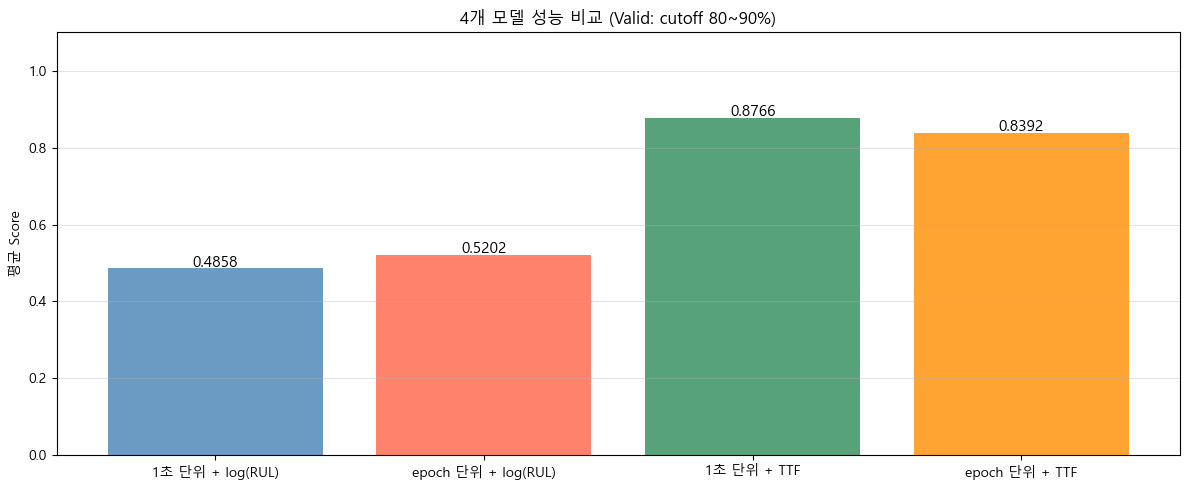


최고 성능: Model C: 1초 단위 + TTF (Score=0.8766)
→ Test 예측 시작
Test1 | 35306s (9.81h)
Test2 | 29162s (8.10h)
Test3 | 29913s (8.31h)
Test4 | 29754s (8.26h)
Test5 | 30244s (8.40h)
Test6 | 38308s (10.64h)


In [ ]:
# ============================================================
# model_cutoff_comparison.py
# cutoff 기반 Train/Valid 분리 + 4개 XGBoost 모델 비교
# ============================================================

fix_seed()

XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
)

# cutoff 구간
TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
VALID_CUTOFFS = [0.2, 0.5, 0.8]

EXCLUDE_COLS = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                'rpm', 'train_id', 'test_id']


# ── cutoff 기반 샘플 생성 ─────────────────────────────────────
def make_cutoff_samples(df, cutoffs, use_epoch=False):
    """
    각 cutoff 시점까지의 데이터 → 마지막 행을 예측 대상으로
    반환: [(features, RUL, TTF), ...]
    """
    samples = []

    for tid in df['train_id'].unique():
        df_t  = df[df['train_id'] == tid].copy()
        ttf   = df_t['ttf'].iloc[0]
        t_max = df_t['t_abs'].max()

        for co in cutoffs:
            cutoff_t = ttf * co
            df_cut   = df_t[df_t['t_abs'] <= cutoff_t]
            if len(df_cut) == 0:
                continue

            if use_epoch:
                # epoch 단위: 마지막 epoch의 마지막 행
                last_epoch = df_cut['epoch'].max()
                df_cut     = df_cut[df_cut['epoch'] == last_epoch]

            last_row = df_cut.loc[df_cut['t_abs'].idxmax()]
            rul      = float(ttf - last_row['t_abs'])
            samples.append({
                'train_id': tid,
                'cutoff':   co,
                'ttf':      ttf,
                'RUL':      rul,
                't_abs':    float(last_row['t_abs']),
                **{c: last_row[c] for c in df_cut.columns
                   if c not in EXCLUDE_COLS + ['train_id']}
            })

    return pd.DataFrame(samples)


# ── 모델 학습 및 평가 ─────────────────────────────────────────
def run_model(df_raw, target, use_epoch, use_log, label):
    """
    target: 'RUL' or 'ttf'
    use_epoch: 1초 단위 vs epoch 단위
    use_log: 로그 변환 여부
    """
    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')

    # 트렌드 피처 추가
    group_col = 'train_id'
    if use_epoch:
        df_feat = aggregate_epoch(df_raw)
        df_feat = add_trend_features(df_feat, windows=[3, 5],
                                      group_col=group_col)
    else:
        df_feat = add_trend_features(df_raw, windows=[5, 10],
                                      group_col=group_col)
    df_feat = df_feat.copy().fillna(0)

    # cutoff 샘플 생성
    df_train_samples = make_cutoff_samples(df_feat, TRAIN_CUTOFFS,
                                            use_epoch=use_epoch)
    df_valid_samples = make_cutoff_samples(df_feat, VALID_CUTOFFS,
                                            use_epoch=use_epoch)

    feat_cols = [c for c in df_train_samples.columns
                 if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]

    print(f'  피처 수: {len(feat_cols)}개')
    print(f'  Train 샘플: {len(df_train_samples)}개 '
          f'(cutoff {TRAIN_CUTOFFS})')
    print(f'  Valid 샘플: {len(df_valid_samples)}개 '
          f'(cutoff {VALID_CUTOFFS})')

    X_train = df_train_samples[feat_cols].values
    X_valid = df_valid_samples[feat_cols].values

    # 타겟 설정
    if target == 'RUL':
        y_train_raw = df_train_samples['RUL'].values
        y_valid_raw = df_valid_samples['RUL'].values
    else:  # ttf
        y_train_raw = df_train_samples['ttf'].values
        y_valid_raw = df_valid_samples['ttf'].values

    if use_log:
        y_train = np.log1p(y_train_raw)
    else:
        y_train = y_train_raw

    # 학습
    fix_seed()
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)

    # Valid 평가
    pred_raw = model.predict(X_valid)
    if use_log:
        pred_vals = np.expm1(pred_raw)
    else:
        pred_vals = pred_raw

    # RUL 기준으로 score 계산
    if target == 'ttf':
        # ttf 예측 → RUL 변환
        pred_rul_arr = np.maximum(
            pred_vals - df_valid_samples['t_abs'].values, 0)
        act_rul_arr  = df_valid_samples['RUL'].values
    else:
        pred_rul_arr = np.maximum(pred_vals, 0)
        act_rul_arr  = y_valid_raw

    scores = [calc_score(a, p)
              for a, p in zip(act_rul_arr, pred_rul_arr)]
    mae    = float(np.mean(np.abs(act_rul_arr - pred_rul_arr)))

    print(f'\n  === Valid 결과 (cutoff별) ===')
    for co in VALID_CUTOFFS:
        mask   = df_valid_samples['cutoff'].values == co
        s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
        mae_co = float(np.mean(np.abs(
            act_rul_arr[mask] - pred_rul_arr[mask])))
        print(f'  cutoff={int(co*100)}% | '
              f'평균Score={s_co:.4f} | MAE={mae_co:.0f}s')

    avg_score = float(np.mean(scores))
    print(f'\n  전체 평균 Score: {avg_score:.4f} | MAE: {mae:.0f}s')

    # Train별 cutoff 80% 예측 시각화
    print(f'\n  === Train별 80% 시점 예측 ===')
    mask_80 = df_valid_samples['cutoff'].values == 0.8
    df_v80  = df_valid_samples[mask_80].reset_index(drop=True)
    p80     = pred_rul_arr[mask_80]
    for i, row in df_v80.iterrows():
        a = row['RUL']
        p = p80[i]
        s = calc_score(a, p)
        print(f'  Train{int(row["train_id"])} | '
              f'실제={a:.0f}s | 예측={p:.0f}s | Score={s:.4f}')

    return model, feat_cols, avg_score, scores


# ── 데이터 로드 ───────────────────────────────────────────────
df_raw = load_train_data()
print(f'Train 전체: {len(df_raw)}행')

# ── 4개 모델 실행 ─────────────────────────────────────────────
MODEL_CONFIGS = [
    dict(target='RUL', use_epoch=False, use_log=True,
         label='Model A: 1초 단위 + log(RUL)'),
    dict(target='RUL', use_epoch=True,  use_log=True,
         label='Model B: epoch 단위 + log(RUL)'),
    dict(target='ttf', use_epoch=False, use_log=False,
         label='Model C: 1초 단위 + TTF'),
    dict(target='ttf', use_epoch=True,  use_log=False,
         label='Model D: epoch 단위 + TTF'),
]

all_models   = {}
score_summary = {}

for cfg in MODEL_CONFIGS:
    model, feat_cols, avg_score, scores = run_model(
        df_raw, **cfg
    )
    key = cfg['label']
    all_models[key]    = {'model': model, 'feat_cols': feat_cols,
                           'cfg': cfg}
    score_summary[key] = avg_score

# ── 성능 비교 시각화 ──────────────────────────────────────────
print('\n\n=== 4개 모델 성능 비교 ===')
for label, score in sorted(score_summary.items(),
                             key=lambda x: -x[1]):
    print(f'  {label:45s} | Score={score:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
labels = [k.split(':')[1].strip() for k in score_summary.keys()]
scores = list(score_summary.values())
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

bars = ax.bar(labels, scores, color=colors, alpha=0.8)
for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{s:.4f}', ha='center', fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_ylabel('평균 Score')
ax.set_title('4개 모델 성능 비교 (Valid: cutoff 80~90%)')
ax.grid(True, axis='y', alpha=0.35)
plt.tight_layout()
os.makedirs('../output', exist_ok=True)
plt.savefig('../output/model_comparison.png', bbox_inches='tight')
plt.show()

# ── 최고 성능 모델로 Test 예측 ───────────────────────────────
best_label = max(score_summary, key=score_summary.get)
best_cfg   = all_models[best_label]
print(f'\n최고 성능: {best_label} (Score={score_summary[best_label]:.4f})')
print('→ Test 예측 시작')

df_test = load_test_data()
if df_test is not None:
    cfg      = best_cfg['cfg']
    feat_cols = best_cfg['feat_cols']
    model    = best_cfg['model']

    if cfg['use_epoch']:
        df_test_feat = aggregate_epoch(df_test)
        df_test_feat = add_trend_features(df_test_feat, windows=[3,5],
                                           group_col='test_id')
    else:
        df_test_feat = add_trend_features(df_test, windows=[5,10],
                                           group_col='test_id')
    df_test_feat = df_test_feat.copy().fillna(0)

    results = []
    for tid in sorted(df_test_feat['test_id'].unique()):
        df_t     = df_test_feat[df_test_feat['test_id'] == tid]
        last_row = df_t.loc[df_t['t_abs'].idxmax()]

        feat_vals = np.array([
            last_row[c] if c in last_row.index else 0.0
            for c in feat_cols
        ]).reshape(1, -1)

        pred_raw = float(model.predict(feat_vals)[0])

        if cfg['target'] == 'ttf':
            pred_rul = max(pred_raw - float(last_row['t_abs']), 0)
        else:
            if cfg['use_log']:
                pred_rul = max(float(np.expm1(pred_raw)), 0)
            else:
                pred_rul = max(float(pred_raw), 0)

        results.append({'File': f'Test{tid}',
                         'RUL_Score': round(pred_rul, 2)})
        print(f'Test{tid} | {pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

    # result_df = pd.DataFrame(results)
    # result_df.to_excel('../output/best_model_submission.xlsx', index=False)
    # print('\n=== 성능 비교 best model 파일 ===')
    # print(result_df.to_string(index=False))

이전) 1초 단위 LSTM + LOO + 로그 변환 / epoch XGBoost + LOO

## 성능 비교 